# Finding Curve of Best Fit

## Import libraries to project

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from scipy.optimize import curve_fit
from tqdm import tqdm
from IPython.display import display, Latex
from astropy.table import QTable

## Import data set

Text(0.5, 1.0, 'Raw Data')

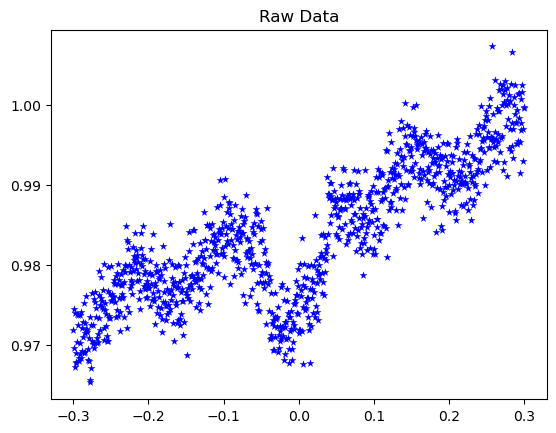

In [2]:
plcData = Table.read("Planet_Lightcurve.fits",format = "fits")
time = np.asarray(plcData["time [days]"])
flux = np.asarray(plcData["flux"])
plt.scatter(time,flux,c='b',marker='*',linewidth=0.0025)
plt.title("Raw Data")

## Define the mathematical functions to be used

$y = (m*x + b) + a * sin(f*x + s)$

Wherein m, b, a, f, and s are all constant parameters

In [3]:
def modelLine(x,m,b):
    '''
    Model a line using the given parameters
        The function of a line is equal to f(x) = mx + b
        
    Input
        x: 1d array of input values
        m: slope of the line
        b: y intercept of the line
    Output
        y: 1d array with the same size as x, each value is equal to f(x)
    '''
    y = x * m
    y += b
    
    return y

def modelSine(x,amp,freq,shift):
    '''
    Model a sinusoid using the given parameters
        The function of a sinusoidal equation is equal to g(x) = amp * sin(freq * x + shift)
        
    Input
        x: 1d array of input values
        amp: amplitude of the sinusoid (how tall it is)
        freq: frequency of the sinusoid (how fast it repeats)
        shift: angle shift of the sinusoid (where it starts)
            (sine and cosine are actually the same function, however cosine is simply shifted forwards 90 degrees
            our sinusoid may not start at the g(0) = 0. For example, the sinusoid may start a third of the way through its oscillation)
    Output
        y: 1d array with the same size as x, each value is equal to g(x)
    '''
    #create the values to input into np.sin(), seperated visually for aesthetics and ease of comprehension
    inputValues = x * freq
    inputValues += shift
    y = np.sin(inputValues)
    y *= amp

    return y
def modelCombination(x,m,b,a,f,s):
    '''
    Model the addition of a sinusoid and a line
        The function of this combination is equal to h(x) = f(x) + g(x)
            Where f(x) and g(x) are the line and sinusoid respectively
        
    Input
        x: 1d array of input values
        m: slope of the line
        b: y intercept of the line
        a: amplitude of the sinusoid (how tall it is)
        f: frequency of the sinusoid (how fast it repeats)
        s: angle shift of the sinusoid (where it starts)
            (sine and cosine are actually the same function, however cosine is simply shifted forwards 90 degrees
            our sinusoid may not start at the g(0) = 0. For example, the sinusoid may start a third of the way through its oscillation)
    Output
        y: 1d array with the same size as x, each value is equal to g(x)
    '''
    #model our line
    line = modelLine(x,m,b)
    #model our sinusoid
    sine = modelSine(x,a,f,s)
    y = line + sine
    return y

## Define the moving mean function, which is used to smoothen data

In [4]:
def movingMean(a, b, window, median = False):
    '''
    Utilizes a moving mean system to smoothen data

    Input
        a: first array of input data to be smoothed (typically some x coordinate)
        b: second array of input data to be smoothed (typically some y coordinate)
        window: integer size of each window that the function will use to smooth data
        median: boolean determining if the function should use median instead of mean
    Output
        smoothA: Array of the same size as a, data within is smoothed via moving mean
        smoothB: Array of the same size as a, data within is smoothed via moving mean
    '''
    smoothA = []
    smoothB = []

    #Check if we'll use median or mean
    if median:
        func = lambda arr: np.nanmedian(arr)
    else:
        func = lambda arr: np.nanmean(arr)

    #Loop
    i = 0
    while i < len(a):
        if(i <= int(window/2) or i >=len(a) - int(window/2)):
            #If too close to the edges, simply use the normal values
            smoothA.append(a[i])
            smoothB.append(b[i])
        else:
            #Otherwise, take the mean or median of the nearby values and append that to our array
            aMed = func(a[i:i+window])
            smoothA.append(aMed)
            bMed = func(b[i:i+window])
            smoothB.append(bMed)
        i +=1
    return np.asarray(smoothA), np.asarray(smoothB)

## Utilize the previously written functions to find the best fit

Text(0.5, 1.0, 'Planet Light Curve Best Fit Smoothed With Moving Mean')

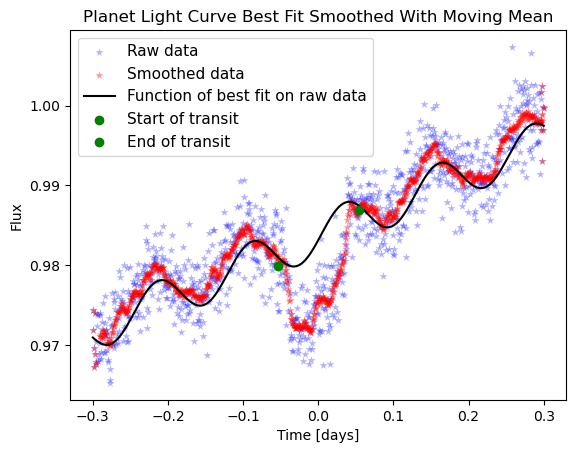

In [5]:
#smoothen out our data
timeSmoothed, fluxSmoothed = movingMean(time,flux,15)

#use scipy.curve_fit() to find a best fit with our smoothed data and the function
params, covariance = curve_fit(modelCombination, timeSmoothed, fluxSmoothed,p0=[1,1,1,50,0],sigma=0.003)

#plot raw data
plt.scatter(time,flux,c='b',marker='*',linewidth=0.0025,alpha=0.3,zorder=1,label="Raw data")
#plot smoothed data
plt.scatter(timeSmoothed,fluxSmoothed,c='r',marker='*',linewidth=0.0025,alpha=0.4,zorder=2,label="Smoothed data")
#plot the calculated best fit
plt.plot(timeSmoothed, modelCombination(timeSmoothed,*params), c='k', zorder=3,label='Function of best fit on raw data')

#plt.errorbar(time,flux,yerr=0.003,c='g',elinewidth=0.01,zorder=0)

plt.scatter(time[411],flux[411],c='g',zorder=5,label="Start of transit")
plt.scatter(time[590],flux[590],c='g',zorder=5,label="End of transit")

plt.xlabel("Time [days]")
plt.ylabel("Flux")
plt.legend(fontsize = 11)
plt.title("Planet Light Curve Best Fit Smoothed With Moving Mean")
#plt.savefig("PlanetLightCurveSmooth.pdf",format="pdf")

## Clear anomalous data to find the true curve of best fit

Text(0.5, 1.0, 'Planet Light Curve Best Fit Smoothed With Moving Mean and Cleaned Data')

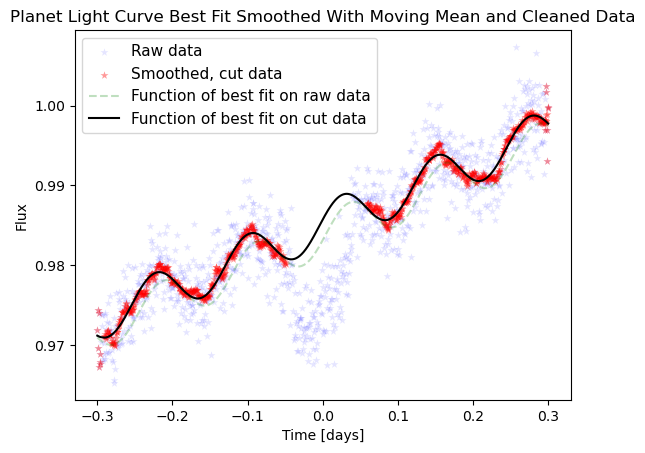

In [6]:
#A distinct anomaly can be found in the region [411:590] from the time and flux arrays
    #Most likely caused by the exoplanet's procession in front of the star
    #We cut the anomalous data, so as to experiment on 'clean' data
timeCutSmoothed = np.concatenate((timeSmoothed[0:411],timeSmoothed[590:]),0)
fluxCutSmoothed = np.concatenate((fluxSmoothed[0:411],fluxSmoothed[590:]),0)

#We find the new parameters based off of our cleaned data
paramsCut, covarianceCut = curve_fit(modelCombination, timeCutSmoothed, fluxCutSmoothed,p0=[1,1,1,50,0],sigma=0.003)

#Plot our various functions and data
plt.scatter(time,flux,c='b',marker='*',linewidth=0.0025,alpha=0.1,zorder=0,label="Raw data")
plt.scatter(timeCutSmoothed,fluxCutSmoothed,c='r',marker='*',linewidth=0.0025,alpha=0.4,zorder=2,label="Smoothed, cut data")

plt.plot(timeSmoothed, modelCombination(timeSmoothed,*params), 'g--', alpha=0.25, zorder=3,label='Function of best fit on raw data')
plt.plot(timeSmoothed, modelCombination(timeSmoothed,*paramsCut), c='k', zorder=4,label='Function of best fit on cut data')

#Adjust our graph
plt.xlabel("Time [days]")
plt.ylabel("Flux")
plt.legend(fontsize = 11)
plt.title("Planet Light Curve Best Fit Smoothed With Moving Mean and Cleaned Data")
#plt.savefig("PlanetLightCurveCut.pdf",format="pdf")

Text(0.5, 1.0, 'Light Curve Linear Portion')

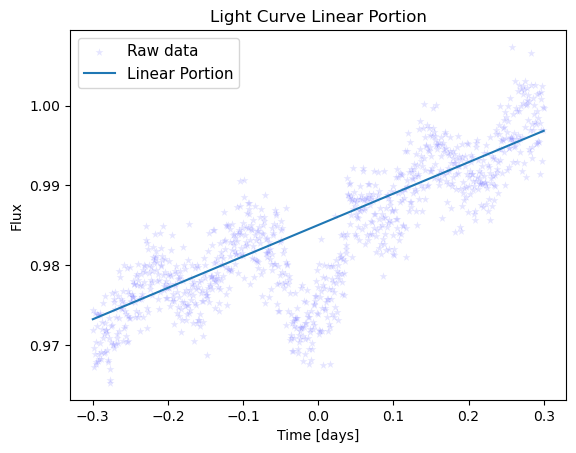

In [7]:
plt.scatter(time,flux,c='b',marker='*',linewidth=0.0025,alpha=0.1,zorder=0,label="Raw data")
plt.plot(time,modelLine(time,paramsCut[0],paramsCut[1]),label="Linear Portion")

plt.xlabel("Time [days]")
plt.ylabel("Flux")
plt.legend(fontsize = 11)
plt.title("Light Curve Linear Portion")

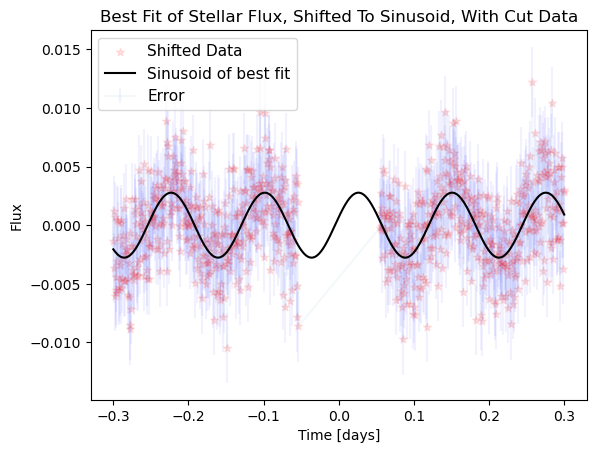

In [8]:
shiftedFlux = flux - modelLine(time,paramsCut[0],paramsCut[1])
timeCut = np.concatenate((time[0:411],time[590:]),0)
fluxCutShifted = np.concatenate((shiftedFlux[0:411],shiftedFlux[590:]),0)

plt.errorbar(x=timeCut,y=fluxCutShifted,yerr=0.003,ecolor='b',alpha=0.05,zorder=0,label="Error")
plt.scatter(timeCut,fluxCutShifted,zorder=1,alpha=0.1,c='r',marker='*',label='Shifted Data')
plt.plot(time,modelSine(time,paramsCut[2],paramsCut[3],paramsCut[4]),c='k',zorder=2,label='Sinusoid of best fit')

plt.xlabel("Time [days]")
plt.ylabel("Flux")
plt.legend(fontsize = 11)
plt.title("Best Fit of Stellar Flux, Shifted To Sinusoid, With Cut Data")
plt.savefig("BestFitSinusoid.pdf",format="pdf")

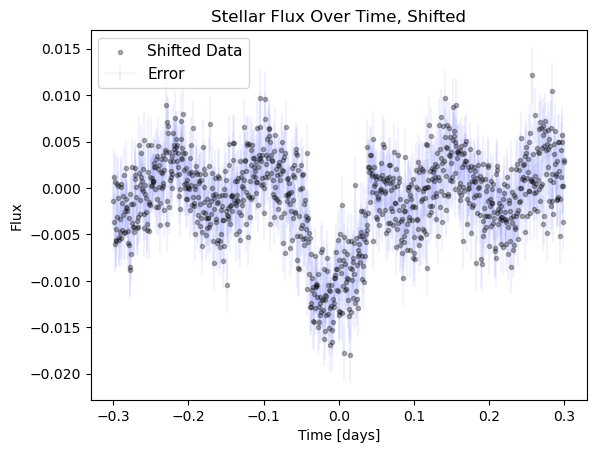

In [12]:
plt.errorbar(x=time,y=shiftedFlux,yerr=0.003,ecolor='b',alpha=0.05,zorder=0,label="Error")
plt.scatter(time,shiftedFlux,zorder=1,alpha=0.3,c='k',marker='.',label='Shifted Data')

plt.xlabel("Time [days]")
plt.ylabel("Flux")
plt.legend(fontsize = 11)
plt.title("Stellar Flux Over Time, Shifted")
plt.savefig("ShiftedData.pdf",format='pdf')